# Painter Classification with FastAI

This notebook presents a complete training and evaluation pipeline for fine-tuning a ResNet50 model on a 50-class painter classification task using the [Best Artworks of All Time](https://www.kaggle.com/datasets/ikarus777/best-artworks-of-all-time) Kaggle dataset.<br>Credit to [Icaro](https://www.kaggle.com/ikarus777) for sharing this excellent dataset!<br>The dataset contains 8,446 paintings from 50 artists, with class imbalance (ranging from ~25 to 800+ paintings per artist).

This notebook uses the FastAI library.<br>
I also created a version using the PyTorch library here: **[PyTorch version](https://www.kaggle.com/code/amarietiberiu/pytorch-painter-classification)**.<br>
For exploratory data analysis on this dataset, check out this notebook: **[EDA](https://www.kaggle.com/code/amarietiberiu/eda-painter-classification)**.


We achieve **~86% accuracy** and **~0.82 macro-average F1** on the validation set.

In [1]:
!pip install -Uqq fastai
!pip uninstall -y fastprogress
!pip install "fastprogress==1.0.3"

^C



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Users\\MichelleJacobs\\Repos\\AIAi\\.venv-1\\Lib\\site-packages\\matplotlib\\_c_internal_utils.cp313-win_amd64.pyd'
Check the permissions.



In [2]:
from fastai.vision.all import *

In [3]:
# Ensure we have the data available
import kagglehub

path = '/kaggle/input/datasets/ikarus777/best-artworks-of-all-time'
if not os.environ.get('KAGGLE_KERNEL_RUN_TYPE', ''):
    path = kagglehub.dataset_download("ikarus777/best-artworks-of-all-time")
data_path = Path(path)/'images'/'images'
print(f"Path exists: {data_path.exists()}") 

Path exists: True


In [4]:
def get_class_from_filename(x: str) -> str:
    """Helper function for extracting the class from the image file name"""
    return x.rsplit("_", 1)[0]

def get_unique_images(x: Path) -> list[Path]:
    """Helper function for collecting all images from the training folder"""
    return [path for path in x.rglob("*.jpg")
            if get_class_from_filename(path.name) != 'Albrecht_Du╠êrer'] # Exclude duplicate folder

In [5]:
# Exclude duplicate folder 'Albrecht_Du╠êrer' (mojibake variant of 'Albrecht Dürer')
labels = [get_class_from_filename(path.name) for path in get_unique_images(data_path)]

dls = ImageDataLoaders.from_name_func(
    data_path,
    get_image_files(data_path, recurse=True, folders=labels),
    get_class_from_filename,
    valid_pct=0.15,
    item_tfms=[Resize(448)],
    bs=32
)

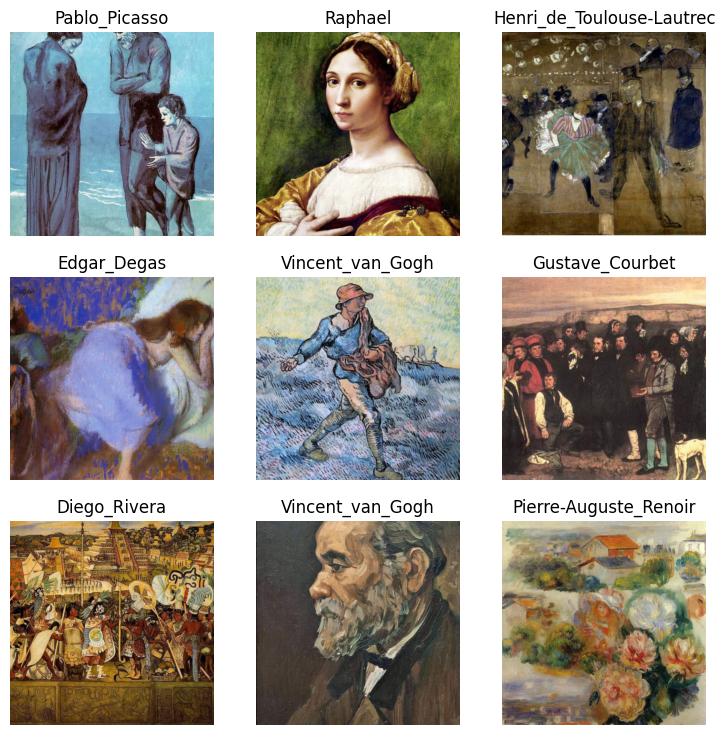

In [6]:
dls.show_batch()

# Training

We will use the powerful transfer learning technique to fine-tune the ResNet50 model, pre-trained on ImageNet, with our dataset. The FastAI library has very good default settings for fine-tuning, so we will keep the custom parameters to a minimum.

In [7]:
learner = vision_learner(dls, resnet50, metrics=[accuracy, F1Score(average='macro')])
learner.fine_tune(15) # Fine tune the model for 15 epochs

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,1.990272,1.269246,0.666667,0.568876,03:33


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,1.127478,0.895747,0.759084,0.687074,04:50
1,0.785778,0.799090,0.781201,0.719254,04:49
2,0.669062,0.666384,0.816746,0.757674,04:49
3,0.506426,0.672536,0.819115,0.764813,04:50
4,0.346398,0.688467,0.818325,0.768679,04:49
5,0.256741,0.608230,0.834123,0.796046,04:49
6,0.167481,0.749430,0.836493,0.790273,04:49
7,0.155612,0.597068,0.847551,0.813663,04:49
8,0.099731,0.548383,0.856240,0.809055,04:49
9,0.072406,0.583326,0.852291,0.811217,04:50


# Results

The model reaches ~86% accuracy with minimal code thanks to FastAI's transfer learning defaults.

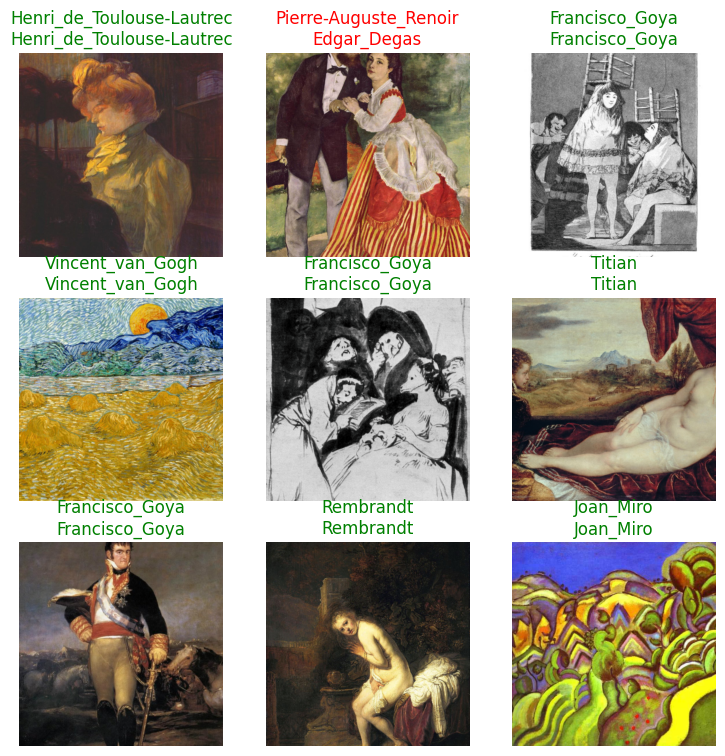

In [8]:
learner.show_results()

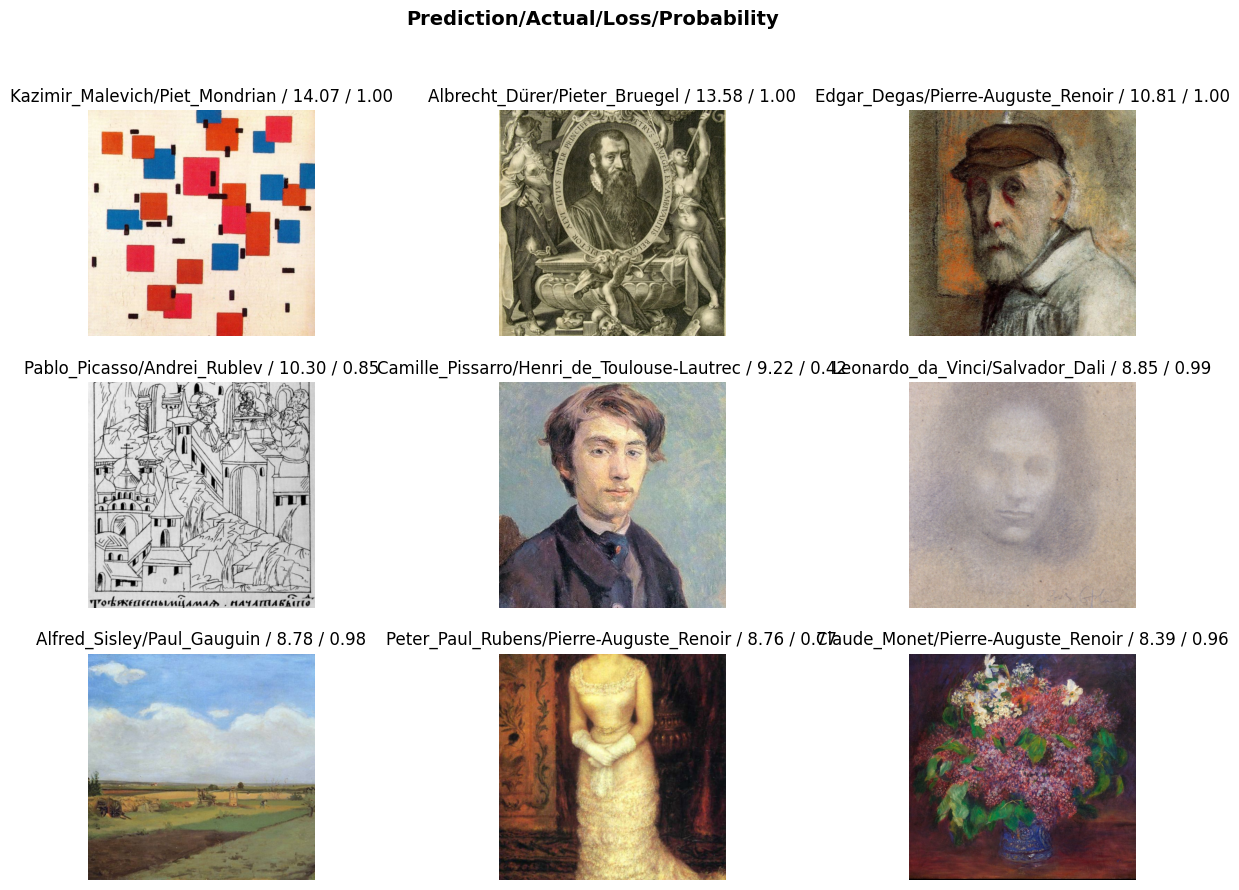

In [9]:
Interpretation.from_learner(learner).plot_top_losses(9, figsize=(15, 10))

#### That's it!
#### Please share your thoughts and feedback in the comments. If you liked the notebook please "upvote" 🔝
#### Check out [https://github.com/Tiberiw](https://github.com/Tiberiw) for other projects I am working on :)